# Topic Modelling

In diesem Notebook werden mit Latent Dirichlet Allocation (LDA) und Non-negative Matrix Factorization (NMF) Themen aus den vorverarbeiteten Steam-Reviews extrahiert.

In [1]:
import hashlib
import pandas as pd

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

file_path = "../data/processed/processed_reviews.jsonlines"

df_model = pd.read_json(
    file_path,
    lines=True
)

df_model.shape

(10988, 5)

In [2]:
bow_vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.95,
    max_features=5000
)

bow_matrix = bow_vectorizer.fit_transform(
    df_model["clean_text"]
)

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.95,
    max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_model["clean_text"]
)

print("Bag-of-Words:", bow_matrix.shape)
print("TF-IDF:", tfidf_matrix.shape)

Bag-of-Words: (10988, 4528)
TF-IDF: (10988, 4528)


## LDA-Basismodell

Latent Dirichlet Allocation modelliert jeden Review als Mischung verschiedener Themen. Jedes Thema wird wiederum durch eine Wahrscheinlichkeitsverteilung über die Wörter beschrieben.

In [3]:
from sklearn.decomposition import LatentDirichletAllocation

number_of_topics = 8

lda_model = LatentDirichletAllocation(
    n_components=number_of_topics,
    learning_method="batch",
    max_iter=10,
    random_state=42,
    n_jobs=-1
)

lda_document_topics = lda_model.fit_transform(bow_matrix)

In [4]:
print("Themen-Wort-Matrix:", lda_model.components_.shape)
print("Dokument-Themen-Matrix:", lda_document_topics.shape)

Themen-Wort-Matrix: (8, 4528)
Dokument-Themen-Matrix: (10988, 8)


## Wichtigste Wörter der LDA-Themen

In [5]:
lda_terms = bow_vectorizer.get_feature_names_out()


def create_topic_table(model, feature_names, number_of_words=12):
    topics = []

    for topic_number, word_weights in enumerate(model.components_):
        top_indices = word_weights.argsort()[-number_of_words:][::-1]

        top_words = [
            feature_names[index]
            for index in top_indices
        ]

        topics.append({
            "topic": f"Thema {topic_number + 1}",
            "top_words": ", ".join(top_words)
        })

    return pd.DataFrame(topics)


lda_topics = create_topic_table(
    lda_model,
    lda_terms,
    number_of_words=12
)

lda_topics

,topic,top_words
0,Thema 1,"game, pc, fps, well, run, console, gta, settin..."
1,Thema 2,"game, play, issue, rockstar, problem, fix, tim..."
2,Thema 3,"game, online, mod, player, loading, rockstar, ..."
3,Thema 4,"ing, club, would, life, game, social, simulato..."
4,Thema 5,"game, gta, best, great, good, story, fun, ever..."
5,Thema 6,"game, gb, rockstar, get, price, pc, good, ram,..."
6,Thema 7,"car, game, get, sale, price, grand, theft, aut..."
7,Thema 8,"game, rockstar, get, money, buy, play, great, ..."


In [6]:
pd.set_option("display.max_colwidth", None)

for _, row in lda_topics.iterrows():
    print(f"{row['topic']}: {row['top_words']}")

Thema 1: game, pc, fps, well, run, console, gta, setting, version, wait, better, graphic
Thema 2: game, play, issue, rockstar, problem, fix, time, even, crash, still, day, review
Thema 3: game, online, mod, player, loading, rockstar, get, people, screen, single, gta, heist
Thema 4: ing, club, would, life, game, social, simulator, play, buy, go, got, like
Thema 5: game, gta, best, great, good, story, fun, ever, like, graphic, one, played
Thema 6: game, gb, rockstar, get, price, pc, good, ram, crash, sale, buy, run
Thema 7: car, game, get, sale, price, grand, theft, auto, like, would, gta, avoid
Thema 8: game, rockstar, get, money, buy, play, great, good, dont, cant, even, card


In [7]:
df_lda = df_model.copy()

df_lda["lda_topic"] = lda_document_topics.argmax(axis=1) + 1
df_lda["lda_topic_probability"] = lda_document_topics.max(axis=1)

df_lda["lda_topic"].value_counts().sort_index()

lda_topic
1    1501
2    1298
3    2227
4     590
5    2258
6     502
7    1192
8    1420
Name: count, dtype: int64

In [8]:
df_lda["review_excerpt"] = (
    df_lda["review"]
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 300)
)

## Manuelle Prüfung der LDA-Themen

Zur inhaltlichen Interpretation werden für jedes Thema die Reviews mit der höchsten Zuordnungswahrscheinlichkeit betrachtet. Dadurch können die Themen benannt und zugleich mögliche themenfremde Ausreißer erkannt werden.

In [ ]:
for topic_number in range(1, 9):
    print(f"\nThema {topic_number}")

    display(
        df_lda.loc[
            df_lda["lda_topic"] == topic_number,
            [
                "lda_topic_probability",
                "rating",
                "review_excerpt"
            ]
        ]
        .sort_values(
            "lda_topic_probability",
            ascending=False
        )
        .head(3)
    )

In [ ]:
for index in [5354, 8928, 6184]:
    print(f"\n--- Review {index} ---")
    print(df_lda.loc[index, "review"])

In [11]:
recipe_mask = df_lda["review"].str.contains(
    r"pie recipe|ingredients:",
    case=False,
    regex=True,
    na=False
)

recipe_mask.sum()

np.int64(4)

In [ ]:
df_lda.loc[
    recipe_mask,
    ["rating", "review"]
]

In [ ]:
for index, row in df_lda.loc[recipe_mask].iterrows():
    print(f"\n--- Review {index} ---")
    print(row["review"])

In [ ]:
df_lda.loc[
    (df_lda["lda_topic"] == 5) & (~recipe_mask),
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(5)

### Entfernung themenfremder Reviews

Bei der Kontrolle der repräsentativen Reviews wurden vier Einträge mit Kuchen- beziehungsweise Waffelrezepten identifiziert. Diese Texte beziehen sich nicht auf das untersuchte Videospiel und wurden daher als Off-Topic-Ausreißer aus der weiteren Themenmodellierung ausgeschlossen.

In [15]:
df_topic = df_model.loc[~recipe_mask].copy()
df_topic = df_topic.reset_index(drop=True)

df_topic.shape

(10984, 5)

## Erneute Modellierung nach der ersten Datenbereinigung

Nach dem Ausschluss der identifizierten Rezepttexte werden die Vektormatrizen neu erstellt und das LDA-Modell erneut trainiert. Dies ist erforderlich, da sich durch die Entfernung von Dokumenten auch das Vokabular und die Themenstruktur verändern können.

In [16]:
bow_vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.95,
    max_features=5000
)

bow_matrix = bow_vectorizer.fit_transform(
    df_topic["clean_text"]
)

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.95,
    max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_topic["clean_text"]
)

print("Bag-of-Words:", bow_matrix.shape)
print("TF-IDF:", tfidf_matrix.shape)

Bag-of-Words: (10984, 4514)
TF-IDF: (10984, 4514)


In [17]:
number_of_topics = 8

lda_model = LatentDirichletAllocation(
    n_components=number_of_topics,
    learning_method="batch",
    max_iter=10,
    random_state=42,
    n_jobs=-1
)

lda_document_topics = lda_model.fit_transform(bow_matrix)

print("Themen-Wort-Matrix:", lda_model.components_.shape)
print("Dokument-Themen-Matrix:", lda_document_topics.shape)

Themen-Wort-Matrix: (8, 4514)
Dokument-Themen-Matrix: (10984, 8)


In [18]:
lda_terms = bow_vectorizer.get_feature_names_out()

lda_topics = create_topic_table(
    lda_model,
    lda_terms,
    number_of_words=12
)

for _, row in lda_topics.iterrows():
    print(f"{row['topic']}: {row['top_words']}")

Thema 1: mod, game, rockstar, banned, online, gta, people, play, player, get, single, ban
Thema 2: game, rockstar, sale, price, money, get, hacker, people, buy, want, online, steam
Thema 3: car, get, would, got, like, kill, cop, go, gun, guy, money, first
Thema 4: game, gta, great, online, fun, good, play, buy, worth, would, story, rockstar
Thema 5: game, loading, screen, best, time, ever, load, play, love, buy, hour, minute
Thema 6: game, online, gta, mission, story, like, player, heist, character, fun, time, mode
Thema 7: game, crash, issue, problem, play, work, fix, rockstar, get, steam, run, time
Thema 8: game, pc, run, fps, gta, version, well, console, graphic, wait, port, rockstar


In [19]:
df_lda = df_topic.copy()

df_lda["lda_topic"] = lda_document_topics.argmax(axis=1) + 1
df_lda["lda_topic_probability"] = lda_document_topics.max(axis=1)

df_lda["review_excerpt"] = (
    df_lda["review"]
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 300)
)

df_lda["lda_topic"].value_counts().sort_index()

lda_topic
1    1323
2    1397
3     964
4    2023
5    1123
6    1384
7     783
8    1987
Name: count, dtype: int64

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 1,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 2,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 3,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 4,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 5,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 6,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 7,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

### Entfernung eines weiteren themenfremden Reviews

Bei der manuellen Kontrolle wurde ein songartiger Off-Topic-Text identifiziert. Damit dieser Eintrag unabhängig von seiner Position im DataFrame reproduzierbar ausgeschlossen werden kann, wird sein SHA-256-Hash verwendet.

In [27]:
song_review_hash = (
    "1765d0ea60cdaf166cd6f62df5ccc7fc"
    "8454a6afe5fbba1f81150c456a00609b"
)

review_hashes = df_topic["review"].map(
    lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest()
)

song_review_mask = review_hashes.eq(song_review_hash)

assert song_review_mask.sum() == 1, (
    "Der themenfremde Review wurde nicht eindeutig gefunden."
)

df_final = df_topic.loc[~song_review_mask].copy()
df_final = df_final.reset_index(drop=True)

print(
    f"Entfernte songartige Off-Topic-Reviews: "
    f"{song_review_mask.sum()}"
)
print(f"Verbleibende Reviews: {len(df_final)}")

df_final.shape

Entfernte songartige Off-Topic-Reviews: 1
Verbleibende Reviews: 10983


(10983, 5)

In [ ]:
df_lda.loc[
    (df_lda["lda_topic"] == 7)
    & (~song_review_mask.reindex(df_lda.index, fill_value=False)),
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(5)

In [ ]:
df_lda.loc[
    df_lda["lda_topic"] == 8,
    [
        "lda_topic_probability",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "lda_topic_probability",
    ascending=False
).head(3)

## Finale Themenmodellierung

Nach der Entfernung des weiteren themenfremden Reviews werden Bag-of-Words und TF-IDF abschließend neu berechnet. Auf diesem endgültigen Datenstand werden LDA und NMF trainiert und miteinander verglichen.

In [30]:
bow_vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.95,
    max_features=5000
)

bow_matrix = bow_vectorizer.fit_transform(
    df_final["clean_text"]
)

tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.95,
    max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_final["clean_text"]
)

print("Bag-of-Words:", bow_matrix.shape)
print("TF-IDF:", tfidf_matrix.shape)

Bag-of-Words: (10983, 4514)
TF-IDF: (10983, 4514)


In [31]:
lda_model = LatentDirichletAllocation(
    n_components=8,
    learning_method="batch",
    max_iter=10,
    random_state=42,
    n_jobs=-1
)

lda_document_topics = lda_model.fit_transform(bow_matrix)

print("Themen-Wort-Matrix:", lda_model.components_.shape)
print("Dokument-Themen-Matrix:", lda_document_topics.shape)

Themen-Wort-Matrix: (8, 4514)
Dokument-Themen-Matrix: (10983, 8)


In [32]:
lda_terms = bow_vectorizer.get_feature_names_out()

lda_topics = create_topic_table(
    lda_model,
    lda_terms,
    number_of_words=12
)

for _, row in lda_topics.iterrows():
    print(f"{row['topic']}: {row['top_words']}")

Thema 1: mod, game, online, banned, rockstar, gta, people, play, player, get, single, ban
Thema 2: game, rockstar, sale, price, money, hacker, get, people, buy, online, want, summer
Thema 3: car, get, would, got, kill, like, cop, go, gun, guy, money, first
Thema 4: game, gta, great, online, fun, good, play, buy, worth, would, story, amazing
Thema 5: game, loading, screen, best, time, ever, load, play, love, buy, good, minute
Thema 6: game, online, gta, mission, story, like, player, heist, fun, time, character, mode
Thema 7: game, crash, play, issue, problem, work, fix, rockstar, steam, get, social, club
Thema 8: game, pc, run, fps, gta, version, well, console, graphic, setting, port, wait


## Benennung und Verteilung der LDA-Themen

Die Themenbezeichnungen werden anhand der jeweils wichtigsten Wörter und der Reviews mit den stärksten Themenzuordnungen vergeben. Anschließend wird jedem Review das am stärksten ausgeprägte Thema zugeordnet, um die Verteilung der Themen im Datensatz darzustellen.

In [33]:
df_lda_final = df_final.copy()

df_lda_final["lda_topic"] = (
    lda_document_topics.argmax(axis=1) + 1
)

df_lda_final["lda_topic_probability"] = (
    lda_document_topics.max(axis=1)
)

In [34]:
lda_topic_names = {
    1: "Modding, Cheating und Bann-Risiken",
    2: "Geschäftspraktiken, Preise und Kaufwarnungen",
    3: "Spielerlebnisse in der offenen Spielwelt",
    4: "Positive Gesamtbewertung und Kaufempfehlung",
    5: "Ladezeiten und Ladebildschirme",
    6: "Story, Einzelspieler und Spielumfang",
    7: "Technische Probleme und Fehlerbehebung",
    8: "PC-Portierung, Performance und Grafik"
}

df_lda_final["lda_topic_name"] = (
    df_lda_final["lda_topic"].map(lda_topic_names)
)

In [35]:
lda_summary = (
    df_lda_final
    .groupby(
        ["lda_topic", "lda_topic_name"]
    )
    .size()
    .reset_index(name="review_count")
    .sort_values("lda_topic")
)

lda_summary["share_percent"] = (
    lda_summary["review_count"]
    / len(df_lda_final)
    * 100
).round(2)

lda_summary

,lda_topic,lda_topic_name,review_count,share_percent
0,1,"Modding, Cheating und Bann-Risiken",1261,11.48
1,2,"Geschäftspraktiken, Preise und Kaufwarnungen",1393,12.68
2,3,Spielerlebnisse in der offenen Spielwelt,961,8.75
3,4,Positive Gesamtbewertung und Kaufempfehlung,2074,18.88
4,5,Ladezeiten und Ladebildschirme,1079,9.82
5,6,"Story, Einzelspieler und Spielumfang",1396,12.71
6,7,Technische Probleme und Fehlerbehebung,839,7.64
7,8,"PC-Portierung, Performance und Grafik",1980,18.03


## NMF-Basismodell

Die Non-negative Matrix Factorization (NMF) zerlegt die TF-IDF-Matrix in eine Dokument-Themen-Matrix und eine Themen-Wort-Matrix. Wie beim LDA-Modell werden zunächst acht Themen verwendet.

In [36]:
from sklearn.decomposition import NMF

number_of_topics = 8

nmf_model = NMF(
    n_components=number_of_topics,
    init="nndsvda",
    random_state=42,
    max_iter=500
)

nmf_document_topics = nmf_model.fit_transform(
    tfidf_matrix
)

print(
    "Themen-Wort-Matrix:",
    nmf_model.components_.shape
)

print(
    "Dokument-Themen-Matrix:",
    nmf_document_topics.shape
)

Themen-Wort-Matrix: (8, 4514)
Dokument-Themen-Matrix: (10983, 8)


In [37]:
nmf_terms = tfidf_vectorizer.get_feature_names_out()

nmf_topics = create_topic_table(
    nmf_model,
    nmf_terms,
    number_of_words=12
)

for _, row in nmf_topics.iterrows():
    print(f"{row['topic']}: {row['top_words']}")

Thema 1: online, play, fun, get, time, friend, would, loading, like, mode, player, heist
Thema 2: best, ever, played, game, one, world, made, far, simulator, gta, open, graphic
Thema 3: mod, banned, rockstar, ban, using, player, single, banning, people, fov, singleplayer, use
Thema 4: game, buy, love, awesome, amazing, nice, year, worth, ing, recommend, rockstar, must
Thema 5: great, game, graphic, port, fun, story, multiplayer, run, amazing, look, gameplay, really
Thema 6: good, pretty, really, graphic, port, game, job, story, computer, fun, nice, gameplay
Thema 7: gta, pc, version, better, console, worth, well, wait, say, run, fps, amazing
Thema 8: sale, price, summer, rockstar, steam, right, move, raising, card, changed, discount, money


In [38]:
df_nmf = df_final.copy()

df_nmf["nmf_topic"] = (
    nmf_document_topics.argmax(axis=1) + 1
)

df_nmf["nmf_topic_weight"] = (
    nmf_document_topics.max(axis=1)
)

df_nmf["review_excerpt"] = (
    df_nmf["review"]
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 300)
)

df_nmf["nmf_topic"].value_counts().sort_index()

nmf_topic
1    3253
2     746
3     956
4    2042
5     729
6     726
7    1838
8     693
Name: count, dtype: int64

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 1,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 2,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [ ]:
df_nmf.loc[
    (df_nmf["nmf_topic"] == 2) &
    (df_nmf["token_count"] >= 5),
    [
        "nmf_topic_weight",
        "rating",
        "token_count",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(5)

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 3,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 4,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [ ]:
df_nmf.loc[
    (df_nmf["nmf_topic"] == 4) &
    (df_nmf["token_count"] >= 5),
    [
        "nmf_topic_weight",
        "rating",
        "token_count",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(5)

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 5,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [ ]:
df_nmf.loc[
    (df_nmf["nmf_topic"] == 5) &
    (df_nmf["token_count"] >= 5),
    [
        "nmf_topic_weight",
        "rating",
        "token_count",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(5)

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 6,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [ ]:
df_nmf.loc[
    (df_nmf["nmf_topic"] == 6) &
    (df_nmf["token_count"] >= 5),
    [
        "nmf_topic_weight",
        "rating",
        "token_count",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(5)

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 7,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [ ]:
df_nmf.loc[
    (df_nmf["nmf_topic"] == 7) &
    (df_nmf["token_count"] >= 5),
    [
        "nmf_topic_weight",
        "rating",
        "token_count",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(5)

In [ ]:
df_nmf.loc[
    df_nmf["nmf_topic"] == 8,
    [
        "nmf_topic_weight",
        "rating",
        "review_excerpt"
    ]
].sort_values(
    "nmf_topic_weight",
    ascending=False
).head(3)

In [52]:
nmf_topic_names = {
    1: "Spielerlebnis in Story- und Onlinemodus",
    2: "Stark positive Superlativ-Bewertungen",
    3: "Modding und Bann-Risiken",
    4: "Positive Gesamtbewertungen und Kaufempfehlungen",
    5: "Positive Qualitätsurteile zu Story, Grafik und Portierung",
    6: "Positive Bewertungen zu Grafik, Story und PC-Version",
    7: "PC-Version, Plattformvergleich und Performance",
    8: "Preisgestaltung und Steam-Sommeraktion"
}

df_nmf["nmf_topic_name"] = (
    df_nmf["nmf_topic"].map(nmf_topic_names)
)

In [53]:
nmf_summary = (
    df_nmf
    .groupby(
        ["nmf_topic", "nmf_topic_name"]
    )
    .size()
    .reset_index(name="review_count")
    .sort_values("nmf_topic")
)

nmf_summary["share_percent"] = (
    nmf_summary["review_count"]
    / len(df_nmf)
    * 100
).round(2)

nmf_summary

,nmf_topic,nmf_topic_name,review_count,share_percent
0,1,Spielerlebnis in Story- und Onlinemodus,3253,29.62
1,2,Stark positive Superlativ-Bewertungen,746,6.79
2,3,Modding und Bann-Risiken,956,8.70
3,4,Positive Gesamtbewertungen und Kaufempfehlungen,2042,18.59
4,5,"Positive Qualitätsurteile zu Story, Grafik und Portierung",729,6.64
5,6,"Positive Bewertungen zu Grafik, Story und PC-Version",726,6.61
6,7,"PC-Version, Plattformvergleich und Performance",1838,16.73
7,8,Preisgestaltung und Steam-Sommeraktion,693,6.31


## Vergleich der Themenverteilungen

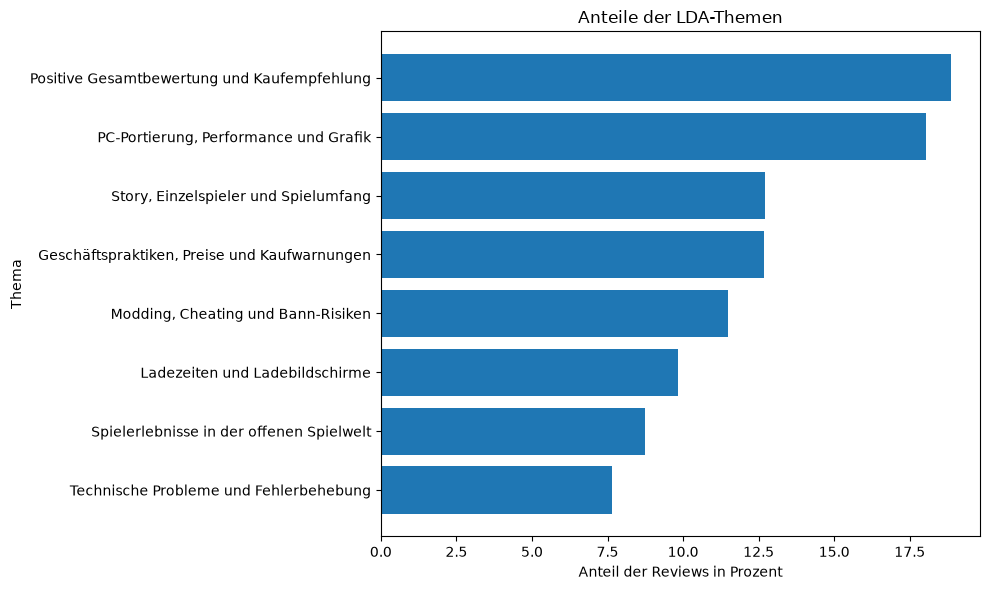

In [54]:
import matplotlib.pyplot as plt

lda_plot = lda_summary.sort_values(
    "share_percent",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    lda_plot["lda_topic_name"],
    lda_plot["share_percent"]
)

plt.title("Anteile der LDA-Themen")
plt.xlabel("Anteil der Reviews in Prozent")
plt.ylabel("Thema")
plt.tight_layout()
plt.show()

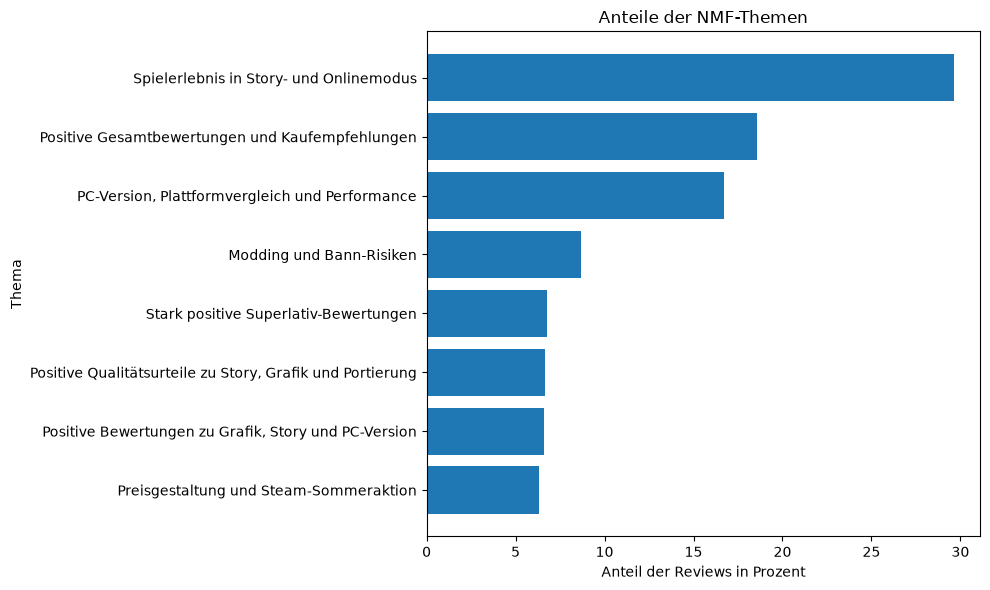

In [55]:
nmf_plot = nmf_summary.sort_values(
    "share_percent",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    nmf_plot["nmf_topic_name"],
    nmf_plot["share_percent"]
)

plt.title("Anteile der NMF-Themen")
plt.xlabel("Anteil der Reviews in Prozent")
plt.ylabel("Thema")
plt.tight_layout()
plt.show()

## Vergleich und Bewertung der Modelle

Beide Verfahren konnten wiederkehrende Muster in den Reviews identifizieren. Das LDA-Modell erzeugte überwiegend inhaltlich unterscheidbare Themen, darunter Modding und Bann-Risiken, Preisgestaltung, Ladezeiten, technische Probleme, Story und Einzelspielermodus sowie PC-Performance.

Das NMF-Modell erkannte ebenfalls relevante Themen wie Modding, Preisgestaltung und Plattformvergleiche. Mehrere NMF-Themen wurden jedoch vor allem durch unterschiedliche positive Bewertungswörter wie „best“, „great“ und „good“ voneinander getrennt. Dadurch waren diese Themen sprachlich unterscheidbar, inhaltlich aber teilweise ähnlich.

Für die abschließende Interpretation wird daher das LDA-Modell bevorzugt, weil seine Themen stärker konkrete Eigenschaften und Probleme des Spiels abbilden. Die Ergebnisse zeigen zugleich, dass Topic Modelling nicht nur Sachthemen, sondern auch Bewertungsstile, wiederholte Formulierungen und themenfremde Ausreißer erfassen kann.

Die festgelegte Zahl von acht Themen wurde explorativ gewählt. Eine systematische Optimierung der Themenzahl und eine zusätzliche quantitative Bewertung der Themenkohärenz könnten die Analyse künftig verbessern.

## Export der Ergebnisse

Die Themenbezeichnungen, Themenverteilungen und wichtigsten Wörter werden als CSV-Dateien gespeichert. Die Datei `review_topic_assignments.jsonlines` enthält darüber hinaus für jeden Review die jeweilige LDA- und NMF-Themenzuordnung sowie die Stärke dieser Zuordnung.

In [56]:
from pathlib import Path

# Speicherort festlegen
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)


# Themenwörter des LDA-Modells vorbereiten
lda_topic_words = lda_topics.copy()

lda_topic_words["topic_number"] = range(
    1,
    len(lda_topic_words) + 1
)

lda_topic_words["topic_name"] = (
    lda_topic_words["topic_number"].map(lda_topic_names)
)

lda_topic_words = lda_topic_words[
    ["topic_number", "topic_name", "top_words"]
]


# Themenwörter des NMF-Modells vorbereiten
nmf_topic_words = nmf_topics.copy()

nmf_topic_words["topic_number"] = range(
    1,
    len(nmf_topic_words) + 1
)

nmf_topic_words["topic_name"] = (
    nmf_topic_words["topic_number"].map(nmf_topic_names)
)

nmf_topic_words = nmf_topic_words[
    ["topic_number", "topic_name", "top_words"]
]


# Themenzuordnungen der einzelnen Reviews zusammenführen
review_topics = df_final[
    ["rating", "review", "clean_text", "token_count"]
].copy()

review_topics["lda_topic"] = (
    df_lda_final["lda_topic"].to_numpy()
)

review_topics["lda_topic_name"] = (
    df_lda_final["lda_topic_name"].to_numpy()
)

review_topics["lda_topic_probability"] = (
    df_lda_final["lda_topic_probability"].to_numpy()
)

review_topics["nmf_topic"] = (
    df_nmf["nmf_topic"].to_numpy()
)

review_topics["nmf_topic_name"] = (
    df_nmf["nmf_topic_name"].to_numpy()
)

review_topics["nmf_topic_weight"] = (
    df_nmf["nmf_topic_weight"].to_numpy()
)


# Übersichtstabellen als CSV speichern
lda_summary.to_csv(
    results_dir / "lda_topic_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

nmf_summary.to_csv(
    results_dir / "nmf_topic_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

lda_topic_words.to_csv(
    results_dir / "lda_topic_words.csv",
    index=False,
    encoding="utf-8-sig"
)

nmf_topic_words.to_csv(
    results_dir / "nmf_topic_words.csv",
    index=False,
    encoding="utf-8-sig"
)


# Detaillierte Themenzuordnungen als JSONLines speichern
review_topics.to_json(
    results_dir / "review_topic_assignments.jsonlines",
    orient="records",
    lines=True,
    force_ascii=False
)

In [57]:
sorted(file.name for file in results_dir.iterdir())

['lda_topic_summary.csv',
 'lda_topic_words.csv',
 'nmf_topic_summary.csv',
 'nmf_topic_words.csv',
 'review_topic_assignments.jsonlines']